In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('climate_data_aggregated_by_month_and_district.csv')

In [3]:
df

,feature,month,tp,e,ro,t2m,stl1,d2m,stl2,swvl1,swvl2,cvh,cvl,slt
0,A & N Islands_Nicobars,1,0.155895,-0.145155,0.000000,299.957974,301.395849,296.205143,301.395933,7.828219e-07,9.263556e-07,0.000000,0.000000,0.00
1,A & N Islands_Nicobars,2,0.073241,-0.127951,0.000000,300.347773,301.663718,296.253400,301.655300,-1.457989e-06,-8.020846e-08,0.000000,0.000000,0.00
2,A & N Islands_Nicobars,3,0.107033,-0.118626,0.000000,300.728570,302.288358,296.591939,302.276559,-1.509114e-06,-8.345849e-07,0.000000,0.000000,0.00
3,A & N Islands_Nicobars,4,0.134209,-0.101045,0.000000,300.984711,302.984163,297.179667,302.976795,-2.279712e-07,2.165511e-06,0.000000,0.000000,0.00
4,A & N Islands_Nicobars,5,0.265185,-0.136944,0.000000,300.947370,302.708544,297.735900,302.719828,3.265345e-07,-1.801931e-06,0.000000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9271,West Bengal_Purulia,8,0.286655,-0.108605,0.091595,301.316108,301.991658,298.498164,301.356652,4.016572e-01,4.017722e-01,0.317097,0.668795,2.25
9272,West Bengal_Purulia,9,0.232007,-0.106522,0.097131,301.040230,301.816350,298.070948,301.156227,3.893341e-01,3.896617e-01,0.317097,0.668795,2.25
9273,West Bengal_Purulia,10,0.092837,-0.102173,0.072248,299.260643,300.044396,294.979955,299.625393,3.149695e-01,3.254036e-01,0.317097,0.668795,2.25
9274,West Bengal_Purulia,11,0.008047,-0.069953,0.029248,295.191450,296.073610,289.408941,296.285416,2.077455e-01,2.354825e-01,0.317097,0.668795,2.25


In [76]:
import pandas as pd
import numpy as np

def extract_climate_features(df):
    """
    Extract annual + seasonal agro-climate features for each district.

    Expected columns:
    feature, month, tp, e, ro, t2m, stl1, d2m, stl2, swvl1, swvl2, cvh, cvl, slt
    """

    df = df.copy()
    df['location'] = df['feature']

    # -----------------------------
    # Season mapping
    # -----------------------------
    season_map = {
        1: "rabi", 2: "zaid", 3: "zaid",
        4: "zaid", 5: "zaid",
        6: "kharif", 7: "kharif", 8: "kharif", 9: "kharif", 10: "rabi",
        11: "rabi", 12: "rabi"
    }

    df["season"] = df["month"].map(season_map)

    climate_vars = [
        "tp", "e", "ro", "t2m", "d2m",
        "stl1", 
        #"stl2",
        "swvl1", 
        #"swvl2"
    ]

    results = []

    for location, group in df.groupby("location"):

        group = group.sort_values("month").reset_index(drop=True)
        feat = {"location": location}

        ## =========================================================
        ##    ORIGINAL MONTHLY VARIABLES (keep as features)
        ## =========================================================
        #for var in climate_vars:
        #    for i in range(12):
        #        feat[f"{var}_m{i+1}"] = group.loc[i, var]

        # =========================================================
        #    ANNUAL FEATURES
        # =========================================================
        #for var in climate_vars:
        #    vals = group[var].values

        #    feat[f"{var}_annual_mean"] = np.mean(vals)
        #    feat[f"{var}_annual_std"] = np.std(vals)
        #    feat[f"{var}_annual_max"] = np.max(vals)
        #    feat[f"{var}_annual_min"] = np.min(vals)
        #    #feat[f"{var}_annual_p90"] = np.percentile(vals, 90)
        #    #feat[f"{var}_annual_p10"] = np.percentile(vals, 10)

        #    #if var == "tp":
        #    #    feat["tp_annual_total"] = np.sum(vals)

        # =========================================================
        #    SEASONAL FEATURES
        # =========================================================
        for season in ["kharif", "rabi", "zaid"]:

            sgroup = group[group["season"] == season]

            for var in climate_vars:

                vals = sgroup[var].values
                if len(vals) == 0:
                    continue

                if not (var == "t2m" and season in ["kharif", "rabi"]):
                    feat[f"{var}_{season}_mean"] = np.mean(vals)
                    
                feat[f"{var}_{season}_std"] = np.std(vals)
                feat[f"{var}_{season}_max"] = np.max(vals)
                feat[f"{var}_{season}_min"] = np.min(vals)

                #if var == "tp":
                #    feat[f"tp_{season}_total"] = np.sum(vals)

        # =========================================================
        #    PRECIPITATION STRUCTURE FEATURES
        # =========================================================
        tp = group["tp"].values

        feat["tp_amplitude"] = np.max(tp) - np.min(tp)

        # Peak month (cyclic encoding)
        peak_month = group.loc[group["tp"].idxmax(), "month"]
        feat["tp_peak_sin"] = np.sin(2 * np.pi * peak_month / 12)
        feat["tp_peak_cos"] = np.cos(2 * np.pi * peak_month / 12)

        # PCI
        tp_sum = np.sum(tp)
        if tp_sum > 0:
            feat["tp_PCI"] = (np.sum(tp**2) / (tp_sum**2)) * 100
        else:
            feat["tp_PCI"] = 0

        # rainfall concentration in kharif
        kharif_total = group[group["season"] == "kharif"]["tp"].sum()
        feat["tp_kharif_fraction"] = kharif_total / tp_sum if tp_sum > 0 else 0

        # =========================================================
        #    TEMPERATURE FEATURES
        # =========================================================
        t2m = group["t2m"].values

        feat["t2m_amplitude"] = np.max(t2m) - np.min(t2m)

        peak_month = group.loc[group["t2m"].idxmax(), "month"]
        feat["t2m_peak_sin"] = np.sin(2 * np.pi * peak_month / 12)
        feat["t2m_peak_cos"] = np.cos(2 * np.pi * peak_month / 12)

        # Growing Degree Days (base = 10C = 283.15K)
        feat["GDD_annual"] = np.sum(np.maximum(t2m - 283.15, 0))

        # seasonal GDD
        for season in ["kharif", "rabi", "zaid"]:
            svals = group[group["season"] == season]["t2m"].values
            if len(svals) > 0:
                feat[f"GDD_{season}"] = np.sum(np.maximum(svals - 283.15, 0))

        # heat stress months
        feat["heat_months_30C"] = np.sum(t2m > 303)
        feat["heat_months_35C"] = np.sum(t2m > 308)

        # =========================================================
        #    HUMIDITY INDEX
        # =========================================================
        feat["humidity_index_annual"] = np.mean(group["t2m"] - group["d2m"])

        # =========================================================
        #    SOIL MOISTURE STRESS
        # =========================================================
        for var in ["swvl1", "swvl2"]:
            vals = group[var].values
            feat[f"{var}_amplitude"] = np.max(vals) - np.min(vals)

        # =========================================================
        #    EVAPORATION / RAIN RATIO
        # =========================================================
        e_total = np.abs(group["e"].sum())
        feat["evap_rain_ratio"] = e_total / tp_sum if tp_sum > 0 else 0

        # =========================================================
        #    STATIC VARIABLES
        # =========================================================
        feat["cvh"] = group["cvh"].mode()[0]
        feat["cvl"] = group["cvl"].mode()[0]
        feat["slt"] = group["slt"].iloc[0]

        results.append(feat)

    return pd.DataFrame(results)


# =========================================================
# RUN FEATURE EXTRACTION
# =========================================================

features_df = extract_climate_features(df)

print(features_df.shape)
#view all columns
pd.set_option('display.max_columns', None)
features_df.head()

(773, 104)


,location,tp_kharif_mean,tp_kharif_std,tp_kharif_max,tp_kharif_min,e_kharif_mean,e_kharif_std,e_kharif_max,e_kharif_min,ro_kharif_mean,ro_kharif_std,ro_kharif_max,ro_kharif_min,t2m_kharif_std,t2m_kharif_max,t2m_kharif_min,d2m_kharif_mean,d2m_kharif_std,d2m_kharif_max,d2m_kharif_min,stl1_kharif_mean,stl1_kharif_std,stl1_kharif_max,stl1_kharif_min,swvl1_kharif_mean,swvl1_kharif_std,swvl1_kharif_max,swvl1_kharif_min,tp_rabi_mean,tp_rabi_std,tp_rabi_max,tp_rabi_min,e_rabi_mean,e_rabi_std,e_rabi_max,e_rabi_min,ro_rabi_mean,ro_rabi_std,ro_rabi_max,ro_rabi_min,t2m_rabi_std,t2m_rabi_max,t2m_rabi_min,d2m_rabi_mean,d2m_rabi_std,d2m_rabi_max,d2m_rabi_min,stl1_rabi_mean,stl1_rabi_std,stl1_rabi_max,stl1_rabi_min,swvl1_rabi_mean,swvl1_rabi_std,swvl1_rabi_max,swvl1_rabi_min,tp_zaid_mean,tp_zaid_std,tp_zaid_max,tp_zaid_min,e_zaid_mean,e_zaid_std,e_zaid_max,e_zaid_min,ro_zaid_mean,ro_zaid_std,ro_zaid_max,ro_zaid_min,t2m_zaid_mean,t2m_zaid_std,t2m_zaid_max,t2m_zaid_min,d2m_zaid_mean,d2m_zaid_std,d2m_zaid_max,d2m_zaid_min,stl1_zaid_mean,stl1_zaid_std,stl1_zaid_max,stl1_zaid_min,swvl1_zaid_mean,swvl1_zaid_std,swvl1_zaid_max,swvl1_zaid_min,tp_amplitude,tp_peak_sin,tp_peak_cos,tp_PCI,tp_kharif_fraction,t2m_amplitude,t2m_peak_sin,t2m_peak_cos,GDD_annual,GDD_kharif,GDD_rabi,GDD_zaid,heat_months_30C,heat_months_35C,humidity_index_annual,swvl1_amplitude,swvl2_amplitude,evap_rain_ratio,cvh,cvl,slt
0,A & N Islands_Nicobars,0.212075,0.009158,0.221129,0.201041,-0.144988,0.012498,-0.123782,-0.156149,0.000000,0.000000,0.000000,0.000000,0.233452,300.805850,300.164819,297.355823,0.211078,297.657880,297.076583,301.883758,0.217027,302.225647,301.649650,5.571480e-07,0.000002,0.000003,-0.000002,0.251271,0.058000,0.311875,0.155895,-0.124398,0.017050,-0.106865,-0.145155,0.000000,0.000000,0.000000,0.000000,0.042440,299.957974,299.849725,296.617852,0.270261,296.892183,296.205143,301.579096,0.139464,301.760741,301.395849,9.293026e-07,3.383562e-07,0.000001,5.417028e-07,0.144917,0.072718,0.265185,0.073241,-0.121142,0.013288,-0.101045,-0.136944,0.000000,0.000000,0.000000,0.000000,300.752106,0.253117,300.984711,300.347773,296.940227,0.566450,297.735900,296.253400,302.411196,0.497624,302.984163,301.663718,-7.171351e-07,7.913001e-07,3.265345e-07,-0.000002,0.238634,-0.5,8.660254e-01,9.314572,0.348657,1.134985,0.866025,-0.500000,206.767581,69.329123,67.030034,70.408425,0,0,3.409331,0.000005,0.000004,0.642038,0.000000,0.000000,0.000000
1,A & N Islands_North And Middle Andaman,0.337536,0.009329,0.352092,0.329107,-0.137305,0.010667,-0.120032,-0.148678,0.043175,0.017435,0.069999,0.022465,0.262733,300.683987,299.968929,297.770214,0.220551,298.076550,297.467693,301.513549,0.282234,301.977394,301.270549,1.246314e-01,0.001572,0.126431,0.122108,0.127208,0.088475,0.266116,0.032517,-0.133948,0.013910,-0.113357,-0.149993,0.029397,0.023122,0.067556,0.006818,0.473816,300.356265,299.105631,295.848296,1.164455,297.232913,294.286115,301.080258,0.493746,301.574430,300.381426,9.895371e-02,2.158417e-02,0.123992,6.666784e-02,0.092360,0.097662,0.258952,0.013540,-0.119274,0.013720,-0.108223,-0.142359,0.004219,0.002699,0.008854,0.002330,300.587495,0.872124,301.536886,299.346751,296.157433,1.401062,298.080887,294.354443,302.241582,1.000248,303.326729,300.737489,6.389570e-02,2.435371e-02,1.046961e-01,0.043781,0.338552,-1.0,-1.836970e-16,12.573580,0.605877,2.431255,0.866025,-0.500000,205.117403,68.627663,66.739761,69.749980,0,0,3.651136,0.082650,0.075678,0.700995,0.097324,0.141098,0.964286
2,A & N Islands_South Andamans,0.311476,0.022785,0.337856,0.286357,-0.144685,0.010310,-0.128231,-0.156308,0.007635,0.002231,0.010801,0.004545,0.248290,300.823124,300.138697,297.727409,0.227059,298.032838,297.404247,301.793553,0.243335,302.203175,301.583277,1.675441e-02,0.000099,0.016891,0.016613,0.157951,0.080844,0.267659,0.050480,-0.137583,0.018443,-0.112006,-0.158502,0.004374,0.003152,0.009483,0.001145,0.265482,300.409896,299.677792,296.141853,0.872380,297.129559,294.938378,301.601490,0.400423,301.984724,301.003037,

                 tp_kharif_mean  tp_kharif_std  tp_kharif_max  tp_kharif_min  \
tp_kharif_mean         1.000000       0.673470       0.978938       0.960407   
tp_kharif_std          0.673470       1.000000       0.802109       0.456820   
tp_kharif_max          0.978938       0.802109       1.000000       0.892709   
tp_kharif_min          0.960407       0.456820       0.892709       1.000000   
e_kharif_mean         -0.110295       0.027900      -0.091038      -0.145417   
...                         ...            ...            ...            ...   
swvl2_amplitude        0.084371       0.148555       0.107771       0.069483   
evap_rain_ratio       -0.783238      -0.436107      -0.741573      -0.794456   
cvh                    0.642293       0.341149       0.596985       0.651197   
cvl                   -0.594932      -0.287184      -0.544428      -0.610413   
slt                    0.287356       0.146641       0.260898       0.280310   

                 e_kharif_mean  e_khari

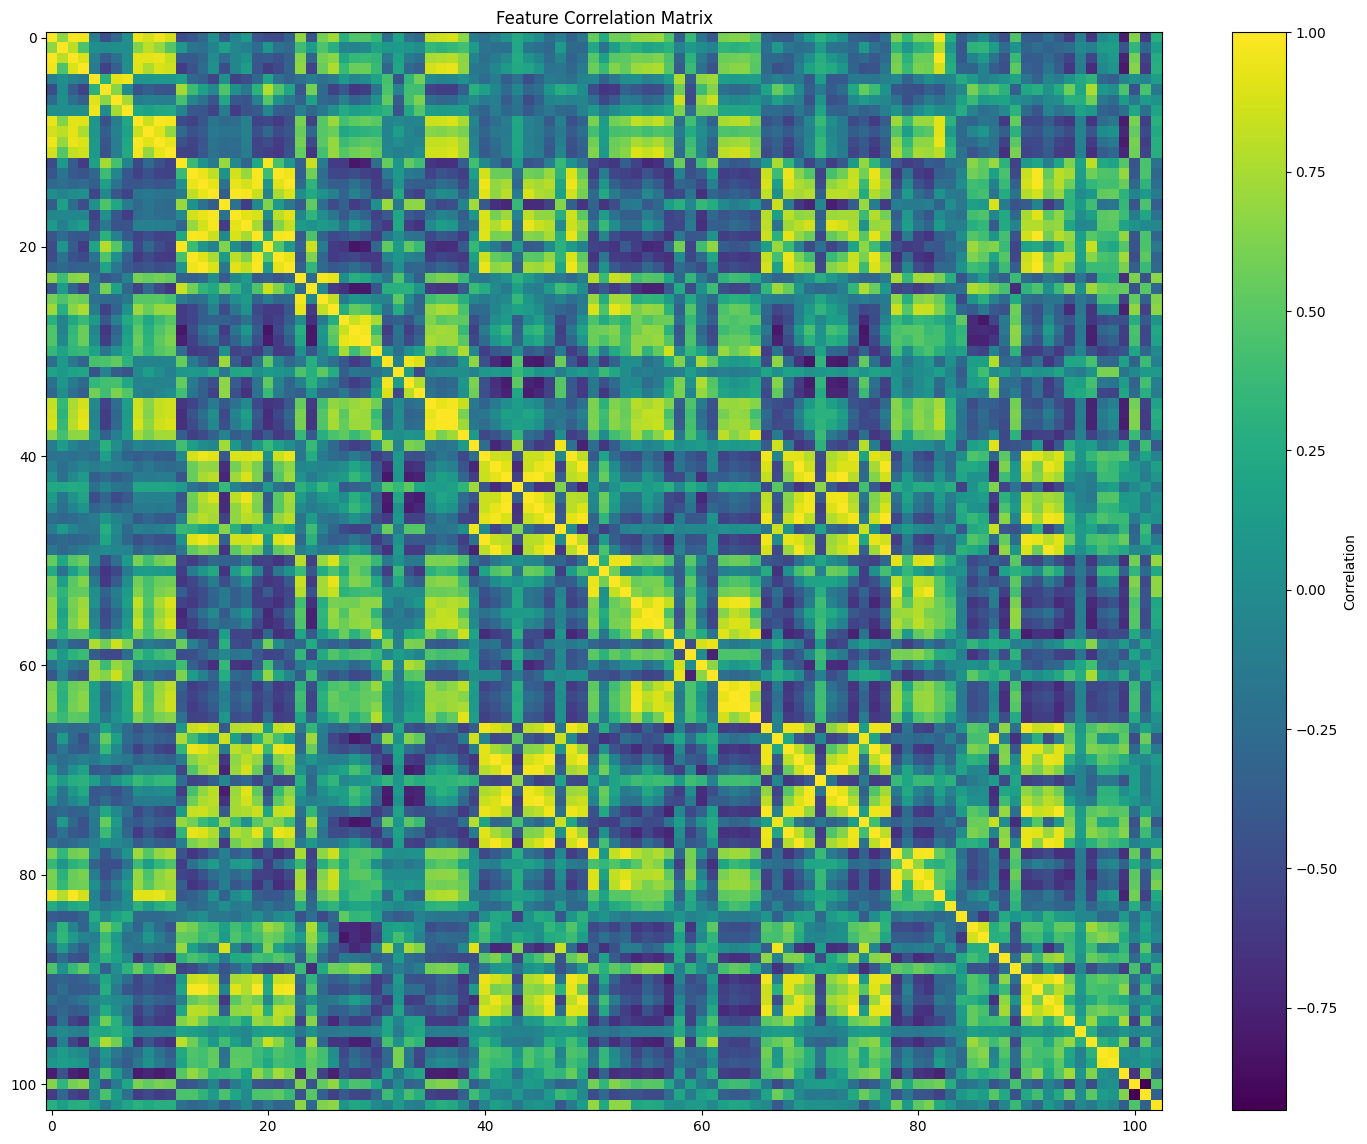

In [77]:
import numpy as np
import pandas as pd

corr_matrix = features_df.drop(columns=["location"]).corr()

print(corr_matrix)

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.show()

In [78]:
corr_matrix.to_csv('feature_correlation_matrix.csv', index=True)

In [79]:
# view top pairs of correlated features which arent reflexive relations
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:  # threshold for high correlation
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

# sort by absolute correlation value
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# display top correlated pairs
for pair in corr_pairs[:1000]:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.5f}")

t2m_kharif_min - stl1_kharif_min: 0.99463
t2m_zaid_max - stl1_zaid_max: 0.99427
d2m_rabi_mean - d2m_rabi_min: 0.99321
stl1_kharif_mean - GDD_kharif: 0.99236
t2m_zaid_mean - stl1_zaid_mean: 0.99117
t2m_kharif_max - stl1_kharif_max: 0.99104
d2m_rabi_min - d2m_zaid_min: 0.99091
d2m_rabi_mean - d2m_zaid_min: 0.99046
t2m_rabi_min - t2m_zaid_min: 0.99003
stl1_rabi_min - stl1_zaid_min: 0.98973
ro_kharif_mean - ro_kharif_max: 0.98973
t2m_rabi_max - stl1_rabi_max: 0.98840
ro_rabi_std - ro_rabi_max: 0.98801
stl1_rabi_mean - stl1_zaid_min: 0.98691
d2m_kharif_mean - d2m_kharif_max: 0.98654
stl1_kharif_mean - stl1_kharif_min: 0.98627
t2m_zaid_min - stl1_zaid_min: 0.98349
tp_kharif_max - tp_amplitude: 0.98323
ro_zaid_std - ro_zaid_max: 0.98307
GDD_annual - GDD_zaid: 0.98289
t2m_kharif_std - stl1_kharif_std: 0.98253
stl1_kharif_min - GDD_kharif: 0.98206
stl1_rabi_mean - t2m_zaid_min: 0.98101
t2m_kharif_max - stl1_kharif_mean: 0.98089
t2m_rabi_min - stl1_rabi_min: 0.98046
d2m_zaid_mean - d2m_zaid_min:

In [80]:
# numver of highly correlated pairs
len(corr_pairs)

376

In [81]:
# most redundant features (appearing most in these pairs)
from collections import Counter
feature_counts = Counter()

for pair in corr_pairs:
    feature_counts[pair[0]] += 1
    feature_counts[pair[1]] += 1

print(feature_counts.most_common(20))

[('t2m_rabi_max', 25), ('stl1_rabi_max', 25), ('t2m_zaid_mean', 24), ('stl1_zaid_mean', 20), ('GDD_annual', 20), ('t2m_zaid_min', 19), ('d2m_rabi_min', 18), ('stl1_rabi_mean', 18), ('d2m_rabi_mean', 17), ('d2m_zaid_min', 17), ('t2m_zaid_max', 16), ('stl1_zaid_max', 16), ('t2m_rabi_min', 16), ('t2m_kharif_min', 15), ('stl1_kharif_min', 15), ('stl1_rabi_min', 15), ('stl1_zaid_min', 15), ('stl1_kharif_mean', 14), ('GDD_kharif', 14), ('t2m_kharif_max', 14)]
